<a href="https://colab.research.google.com/github/riteshkrkumarweb/Learning_AI/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
parvmodi_cgpa_vs_package_in_lpa_path = kagglehub.dataset_download('parvmodi/cgpa-vs-package-in-lpa')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/parvmodi/cgpa-vs-package-in-lpa/placement.csv


**What is Linear Regression ?**

                            Linear Regression is a simple algorithm that tries to create a straight line that passes as close as possible to all the data points. This line is called the best-fit line. It is used when the data has an approximately linear relationship(when one thing changes, the other changes in a straight-line pattern. 1 hour study → 10 marks ,2 hours study → 20 marks ,3 hours study → 30 marks).
                            
**y=mx+b**
❤️ **y → output(Target Column )**
y = output
This is the value we want to predict.
Example:
if we are predicting package, then
y = package
So y is the final answer.

❤️ **x → input(Input column)**
x = input
This is the thing we already know.
Example:
x = CGPA
So we give x to the model, and it predicts y.

❤️ **m → slope / rate of change or weights**
Here m or w means weight.
Weight tells:
how strongly the input affects the output
.x = CGPA
y = Package
Then w means:
how much CGPA influences package
So yes, you can think:
weight of CGPA on package

Package=2(CGPA)+1 same as y = mx+b
Here weight = 2
Meaning:
if CGPA increases by 1
package increases by 2 LPA
You can think like the Experience on the place of the CGPA

if the Exprience is more the Package is more
experience = 1 then package is 10 lakh
experience = 2 then the package is 20 lakh  
So weight is basically:
importance / effect / impact of input on output

❤️ **b → starting value / intercept**
b is the value of output when input is 0.
y = mx+b (x =CGPA)
So if CGPA = 0, package may still not be 0 according to the line.
That starting value is b.
So package starts from 1.
That 1 is the bias/intercept.
You can think that if the x = Experience the if the experience = 0 then the package(y) is also be 0 but when the fresher joins a company they has some package for the freshers.
In Math we say that the line is pass through origin(0,0) , but in real dataset  it often donot start from Origin like the fresher may may get 3L package not 0.
So b helps shift the line up or down to fit the data better.
That is why bias is important.


In [ ]:
df = pd.read_csv('/kaggle/input/datasets/parvmodi/cgpa-vs-package-in-lpa/placement.csv')

In [ ]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [ ]:
df.head(16)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
5,7.89,2.99
6,6.73,2.60
7,6.75,2.48
8,6.09,2.31
9,8.31,3.51


In [ ]:
df.isnull().sum() #Checking that if any data is not null

cgpa       0
package    0
dtype: int64

Text(0.5, 1.0, 'package Graph')

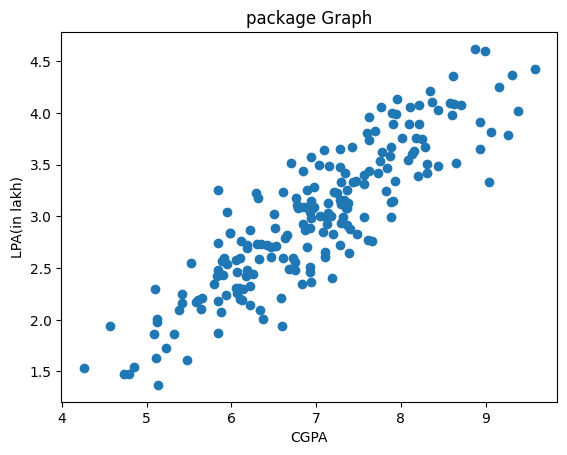

In [ ]:
import matplotlib.pyplot as plt  # EDA using the scatter Plot

plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('LPA(in lakh)')
plt.title('package Graph')

In [ ]:
# This is Correct But in scikit-learn, it is usually better to keep X as 2D
X = iloc[:,0] #This is 1D so write like  X = iloc[:,0:1]
y = iloc[:,-1] # Output Column is enough if it is 1D
# df.iloc[:, 0] gives a Series shape like (199,)
df.iloc[:, [0]]# gives a DataFrame shape like (199, 1)-> 2D
''' how double bracket is 2D ?
    [6.89, 5.12, 7.82, 7.42] Only one direction ->1D

    [[6.89],
     [5.12],
     [7.82],
     [7.42]] -> 2D Rows and columns:
'''
X = df.iloc[:, 0:1] # → 2D


#Ignore the errors



NameError: name 'iloc' is not defined

In [ ]:
X = df.iloc[:,0:1]# All row and 0 column ✅
y = df.iloc[:,-1]# All row and from last one column

In [ ]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [ ]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#20% data will go to test set and the remaining 80% data will go to train set
#42 has no special magic here. It can be 0, 1, 10, 99 too. It is just a fixed number. 42 is used a lot by people as a common example.

In [ ]:
X_train # This is Training set

,cgpa
79,7.18
197,7.21
38,8.62
24,6.53
122,5.12
...,...
106,6.13
14,7.73
92,7.90
179,7.14


In [ ]:
y_train #Training set output column

79     3.00
197    3.24
38     4.36
24     2.71
122    2.01
       ... 
106    2.19
14     3.42
92     4.00
179    3.03
102    1.37
Name: package, Length: 160, dtype: float64

In [ ]:
from sklearn.linear_model import LinearRegression #Import the model
model = LinearRegression()

In [ ]:
model.fit(X_train , y_train) # Train the model fit means Train

LinearRegression()

In [ ]:
X_test

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


In [ ]:
y_test

95     2.79
15     3.23
30     3.26
158    3.04
128    3.34
115    4.21
69     2.94
170    2.87
174    2.99
45     3.58
66     1.63
182    2.08
165    4.08
78     2.21
186    3.47
177    3.64
56     2.74
152    3.08
82     2.17
68     2.99
124    2.31
16     2.35
148    3.40
93     3.08
65     3.81
60     2.19
84     1.53
67     2.89
125    3.16
132    2.48
9      3.51
18     2.98
55     3.39
75     3.28
150    2.73
104    3.74
135    2.60
137    3.13
164    3.82
76     3.15
Name: package, dtype: float64

In [ ]:
# This causes the warning
model.predict(X_test.iloc[2].values.reshape(1,1))
# X_test.iloc[2] -> pandas Series with name 'cgpa'
# .values -> numpy array without feature name

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.1995207])

In [ ]:
'''Here we doing first we take the 1 index of the X_test and
and predict the result then which is array([2.78031348]) like this
then we match the y_test which is our actual value.'''

model.predict(X_test.iloc[[4]]) # Use double brackets to keep it as DataFrame ✅





array([3.52684689])

Text(0.5, 1.0, 'package Graph')

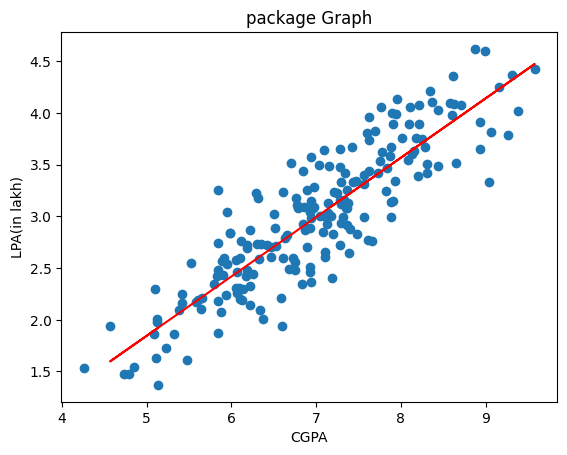

In [ ]:
plt.scatter(df['cgpa'],df['package'])# Plots all data points
#plt.plot(X_test,model.predict(X_test),color='red') #This is the Linear Line
# The Linear Regression has predict on all the X_train data Points

plt.plot(X_train,model.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('LPA(in lakh)')
plt.title('package Graph')

In [ ]:
#In y = mx+b This is the m
#m decides tilt of line
m = model.coef_

array([0.57425647])

In [ ]:
'''Why it is negetive
Because the best-fit line is chosen mathematically
Sometimes to stay close to all points, the line must shift downward a bit.
That makes b negative.
-1.027 means the regression line crosses the y-axis at -1.027, because that gives the best fit to your data.'''
#In y = mx+b This is the
#b decides where line starts on y-axis
b = model.intercept_
print(b)


-1.0270069374542108


In [ ]:
#Make Prediction
y_predict = model.predict(X_test)

In [ ]:
'''accuracy_score compares exact matches, which doesn't make sense for continuous values. For example:
Actual: 5.2 LPA, Predicted: 5.3 LPA
This would be counted as "incorrect" even though it's very close!'''
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_predict) # ❌ Wrong for regression!
# I have done Wrong Not U Write that Learn form Mistakes

ValueError: continuous is not supported

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_predict)
print(f"R² Score: {r2:.4f}")
# Range: 0 to 1 (higher is better)
# 1 = perfect prediction, 0 = model predicts mean

R² Score: 0.7731


In [ ]:
'''
R² < 0.3  → Weak model (explains very little variance)
R² 0.3-0.5 → Moderate model (decent but room for improvement)
R² 0.5-0.7 → Strong model (good predictive power)
R² > 0.7  → Very strong model (excellent fit, but check for overfitting)
'''

'\nR² < 0.3  → Weak model (explains very little variance)\nR² 0.3-0.5 → Moderate model (decent but room for improvement)\nR² 0.5-0.7 → Strong model (good predictive power)\nR² > 0.7  → Very strong model (excellent fit, but check for overfitting)\n'